<a href="https://colab.research.google.com/github/amedellincorte-lab/Personas-mexicanas-deportadas-EEUU--MEX/blob/main/TFM_AMC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Montar paquetes
import pandas as pd
import os
from google.colab import drive
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.cluster import KMeans
!pip install ydata_profiling
from ydata_profiling import ProfileReport
import IPython.display as display
from google.colab import files


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.3 MB/s eta 0:00:00


/tmp/ipykernel_4859/4173078629.py:11: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [ ]:
url="https://raw.githubusercontent.com/amedellincorte-lab/Personas-mexicanas-deportadas-EEUU--MEX/main/Rapatriados_2026.xlsx"
df=pd.read_excel(url)
df.head()

,Año,Mes,Título,Estado (recepción),Punto de recepción,Estado (origen),Estado (destino),Estado (detención EUA),Autoridad,Sexo,Grupo de edad,Tiempo en EUA,Total
0,2026,Enero,8,Baja California,Mexicali I,Aguascalientes,Aguascalientes,California,ICE,Hombre,Adultos,1 a 12 meses,1
1,2026,Enero,8,Baja California,Mexicali I,Baja California,Baja California,California,ICE,Hombre,Adultos,1 a 12 meses,12
2,2026,Enero,8,Baja California,Mexicali I,Baja California,Baja California,California,ICE,Mujer,Adultos,1 a 12 meses,2
3,2026,Enero,8,Baja California,Mexicali I,Baja California,Baja California,California,CBP,Hombre,NNA,1 a 12 meses,3
4,2026,Enero,8,Baja California,Mexicali I,Baja California,Baja California,California,CBP,Hombre,Adultos,1 a 12 meses,30


In [ ]:
#Obtención de datos

# Las bases originales se encuentran en el sitio del gobierno mexicano (Unidad de Política Migratoria y Registro de Identidad de Personas- UPMRIP)
# https://portales.segob.gob.mx/es/PoliticaMigratoria/tablero_estadistica
# Sección: Nota metodológica
#          > Descarga los tabulados que alimentan el tablero
#                  > Repatriados
# Estos los subí a un repositorio público de Github para facilitar que corra el ejercicio sin tener que descargar archivos etc.

# Limpiar nombres de columnas
def clean_columns(df):
    def normalize(text):
        text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
        return text

    df.columns = (
        df.columns.str.strip()              # quitar espacios al inicio/fin
                 .str.lower()               # pasar a minúsculas
                 .map(normalize)            # quitar acentos y ñ
                 .str.replace(" ", "_")     # espacios → guiones bajos
                 .str.replace("(", "", regex=False)  # quitar paréntesis
                 .str.replace(")", "", regex=False)
    )
    return df

# URL base y años para obtener datos
base_url = "https://raw.githubusercontent.com/amedellincorte-lab/Personas-mexicanas-deportadas-EEUU--MEX/main/"
years = range(2016, 2027)

# Cargar hoja específica de cada archivo y limpiar columnas
dataframes = {}
for year in years:
    file = f"Rapatriados_{year}.xlsx"
    url = base_url + file
    df = pd.read_excel(url, sheet_name=0)
    df = clean_columns(df)
    if 'titulo' in df.columns:
        df = df.drop(columns=['titulo'])
    dataframes[year] = df

# Montar todos los años en un solo DataFrame
combined = pd.concat(dataframes.values(), ignore_index=True)

# Revisar estructura
print("Dimensiones:", combined.shape)
print("Columnas:", combined.columns.tolist())
print(combined.head())


Dimensiones: (520431, 12)
Columnas: ['ano', 'mes', 'estado_recepcion', 'punto_de_recepcion', 'estado_origen', 'estado_destino', 'estado_detencion_eua', 'autoridad', 'sexo', 'grupo_de_edad', 'tiempo_en_eua', 'total']
    ano    mes estado_recepcion punto_de_recepcion    estado_origen  \
0  2016  Enero  Baja California         Mexicali I   Aguascalientes   
1  2016  Enero  Baja California         Mexicali I   Aguascalientes   
2  2016  Enero  Baja California         Mexicali I  Baja California   
3  2016  Enero  Baja California         Mexicali I  Baja California   
4  2016  Enero  Baja California         Mexicali I  Baja California   

    estado_destino estado_detencion_eua      autoridad    sexo grupo_de_edad  \
0   Aguascalientes              Arizona  Border Patrol  Hombre       Adultos   
1   Aguascalientes              Arizona            ICE  Hombre       Adultos   
2  Baja California              Arizona  Border Patrol  Hombre       Adultos   
3  Baja California           Californ

# Exploración

In [ ]:
combined.describe()

,ano,total
count,520431.000000,520431.000000
mean,2020.641121,3.927547
std,3.090925,11.875807
min,2016.000000,1.000000
25%,2018.000000,1.000000
50%,2020.000000,1.000000
75%,2023.000000,3.000000
max,2026.000000,749.000000


In [ ]:
# EDA
profile = ProfileReport(combined, title="Reporte EDA Deportaciones", explorative=True)

# Pasar a HTML
profile.to_file("Reporte_EDA.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:13<00:00,  1.14s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
files.download("Reporte_EDA.html")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

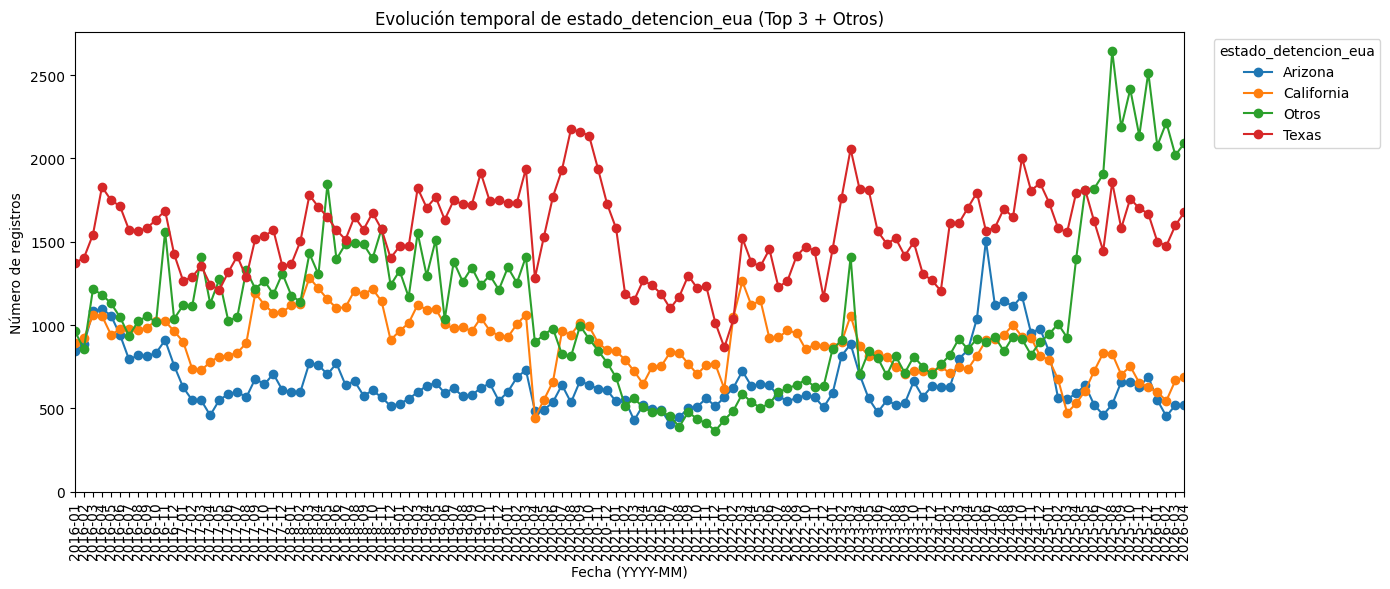

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = combined.copy()

# 1. Crear columna de fecha como string YYYY-MM y luego convertirla
meses = {
    "Enero":1, "Febrero":2, "Marzo":3, "Abril":4, "Mayo":5, "Junio":6,
    "Julio":7, "Agosto":8, "Septiembre":9, "Octubre":10, "Noviembre":11, "Diciembre":12
}
df["mes_num"] = df["mes"].map(meses)
df = df.dropna(subset=["mes_num"])

# Construir columna YYYY-MM
df["fecha_str"] = df["ano"].astype(str) + "-" + df["mes_num"].astype(str).str.zfill(2)
df["fecha"] = pd.to_datetime(df["fecha_str"], format="%Y-%m")

# 2. Función para graficar evolución de categorías principales + "Otros"
def plot_time_series(df, variable, top_n=4):
    grouped = df.groupby(["fecha", variable]).size().reset_index(name="count")
    top_categories = grouped.groupby(variable)["count"].sum().nlargest(top_n).index
    grouped[variable] = grouped[variable].where(grouped[variable].isin(top_categories), "Otros")
    grouped = grouped.groupby(["fecha", variable])["count"].sum().reset_index()
    pivot = grouped.pivot(index="fecha", columns=variable, values="count").fillna(0)

    fig, ax = plt.subplots(figsize=(14,6))
    pivot.plot(ax=ax, kind="line", marker="o")

    ax.set_title(f"Evolución temporal de {variable} (Top {top_n} + Otros)")
    ax.set_ylabel("Número de registros")
    ax.set_xlabel("Fecha (YYYY-MM)")

    # Mostrar cada mes como etiqueta YYYY-MM
    ax.set_xticks(pivot.index)
    ax.set_xticklabels(pivot.index.strftime("%Y-%m"), rotation=90)

    ax.set_ylim(bottom=0)

    ax.legend(title=variable, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# 3. Ejemplo de uso
plot_time_series(df, "estado_detencion_eua", top_n=3)


In [ ]:
# 2. Valores faltantes por columna
print("\nValores faltantes por columna:")
print(data.isnull().sum())


Valores faltantes por columna:
ano                     0
mes                     0
titulo                  0
estado_recepcion        0
punto_de_recepcion      0
estado_origen           0
estado_destino          0
estado_detencion_eua    0
autoridad               0
sexo                    0
grupo_de_edad           0
tiempo_en_eua           0
total                   0
dtype: int64


In [ ]:
# 1. Crear diccionario de coordenadas
coords_dict = {
    "Mexicali I": (32.6277, -115.4545),
    "Tecate": (32.5666, -116.6276),
    "Tijuana, Chaparral": (32.5363, -117.0437),
    "A. I. de Tapachula": (14.7943, -92.3700),
    "Cd. Juárez, Libertad (Paso del Norte)": (31.7390, -106.4870),
    "Ojinaga": (29.5669, -104.4160),
    "A. I. de la Ciudad de México Terminal 1 \"A\"": (19.4361, -99.0719),
    "A.I. Benito Juárez": (19.4361, -99.0719),
    "Cd. Acuña": (29.3232, -100.9522),
    "Piedras Negras II": (28.7040, -100.5230),
    "A. I. Durango": (24.1246, -104.5280),
    "A.I. Guadalajara": (20.5218, -103.3112),
    "A.I. Puerto Vallarta": (20.6800, -105.2500),
    "A.I. Morelia": (19.8490, -101.0250),
    "A.I. Felipe  Ángeles": (19.7571, -99.0164),
    "A.I. Monterrey": (25.7785, -100.1070),
    "A.I. Puebla": (19.1581, -98.3714),
    "A.I. Querétaro": (20.6173, -100.1850),
    "Agua Prieta": (31.3320, -109.5480),
    "Naco": (31.3330, -109.9500),
    "Nogales Uno": (31.3333, -110.9333),
    "San Luis Río Colorado": (32.4630, -114.7710),
    "Sonoyta": (31.8620, -112.8500),
    "A. I. de Villahermosa": (17.9892, -92.9300),
    "A.I. Villahermosa": (17.9892, -92.9300),
    "Nuevo Laredo II \"Juárez-Lincoln\"": (27.4760, -99.5160),
    "Nuevo Laredo II (Juárez-Lincoln)": (27.4760, -99.5160),
    "Nuevo LaredoI (Miguel Alemán)": (27.4760, -99.5160),
    "Puerta México (Matamoros II)": (25.8790, -97.5040),
    "Reynosa-Hidalgo, Benito Juárez I y II": (26.0920, -98.2770),
    "A. I. de Merida": (20.9330, -89.6570)
}

# 2. Convertir a DataFrame y fusionar
coords_df = pd.DataFrame.from_dict(coords_dict, orient="index", columns=["lat","lon"])
coords_df["punto_de_recepcion"] = coords_df.index
data = data.merge(coords_df, on="punto_de_recepcion", how="left")


#############HASTA ACA



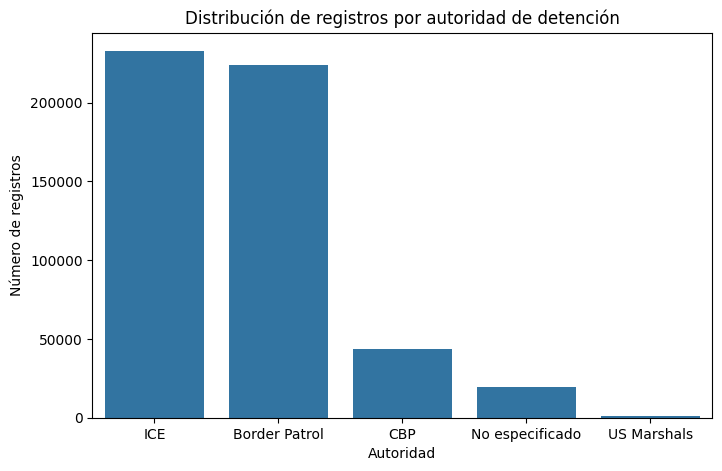

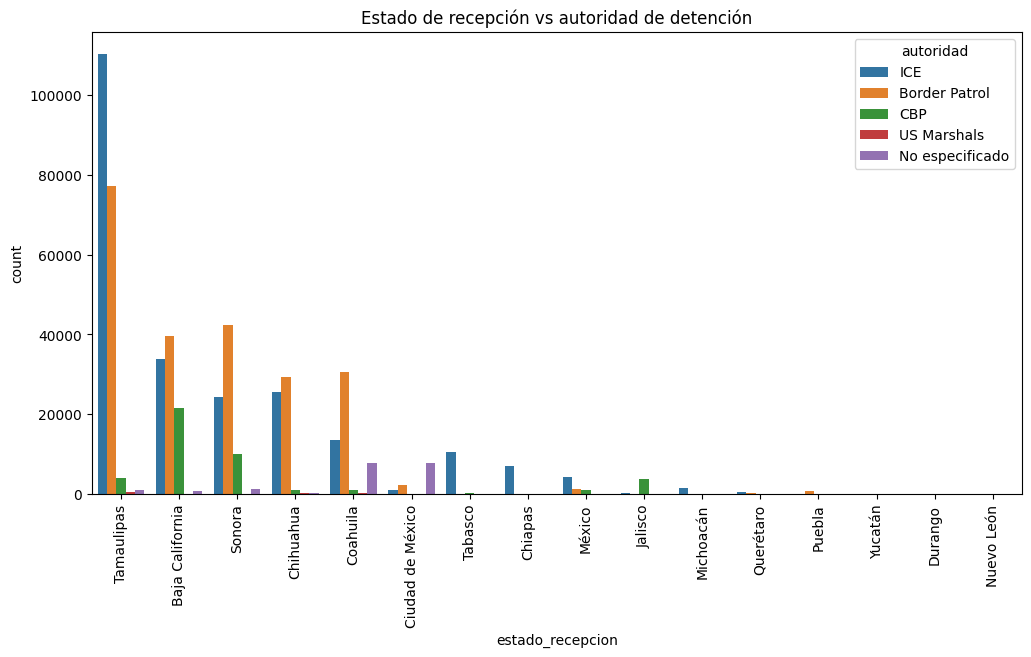

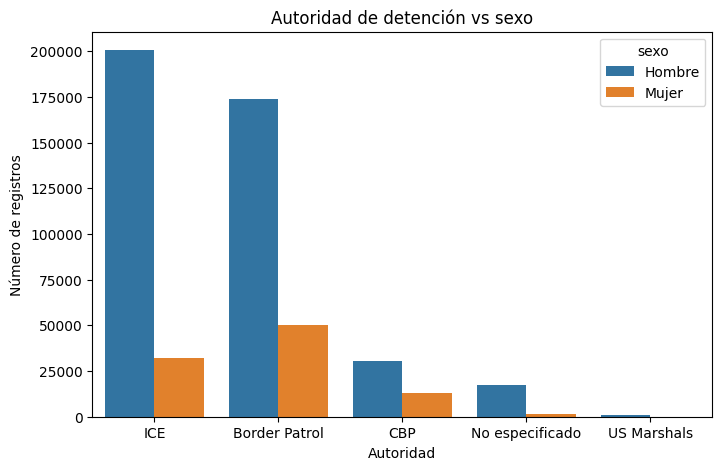

In [ ]:
# Distribución general de autoridades
plt.figure(figsize=(8,5))
sns.countplot(x="autoridad", data=data, order=data['autoridad'].value_counts().index)
plt.title("Distribución de registros por autoridad de detención")
plt.xlabel("Autoridad")
plt.ylabel("Número de registros")
plt.show()

# Cruce: autoridad vs estado de recepción
plt.figure(figsize=(12,6))
sns.countplot(x="estado_recepcion", hue="autoridad", data=data,
              order=data['estado_recepcion'].value_counts().index)
plt.title("Estado de recepción vs autoridad de detención")
plt.xticks(rotation=90)
plt.show()

# Cruce: autoridad vs sexo
plt.figure(figsize=(8,5))
sns.countplot(x="autoridad", hue="sexo", data=data,
              order=data['autoridad'].value_counts().index)
plt.title("Autoridad de detención vs sexo")
plt.xlabel("Autoridad")
plt.ylabel("Número de registros")
plt.show()


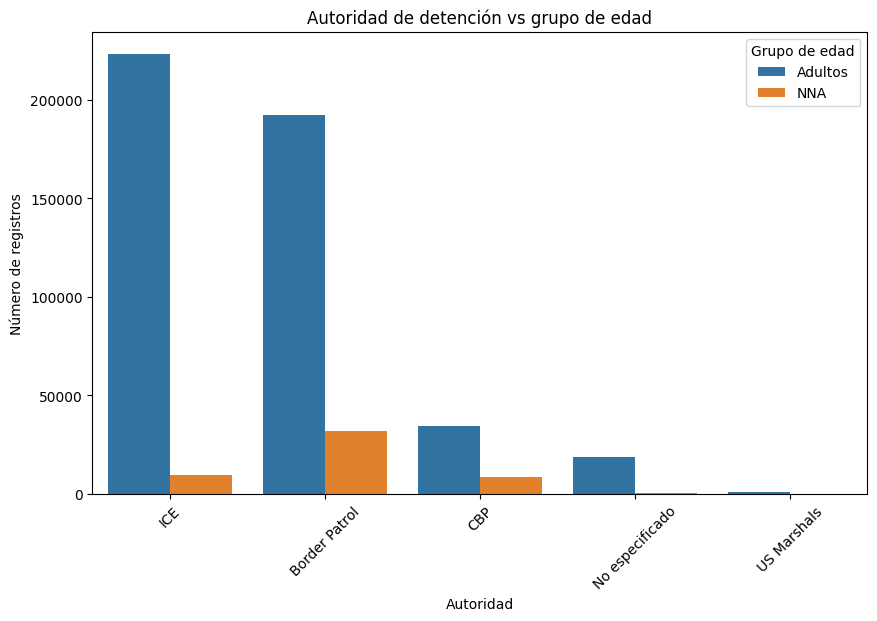

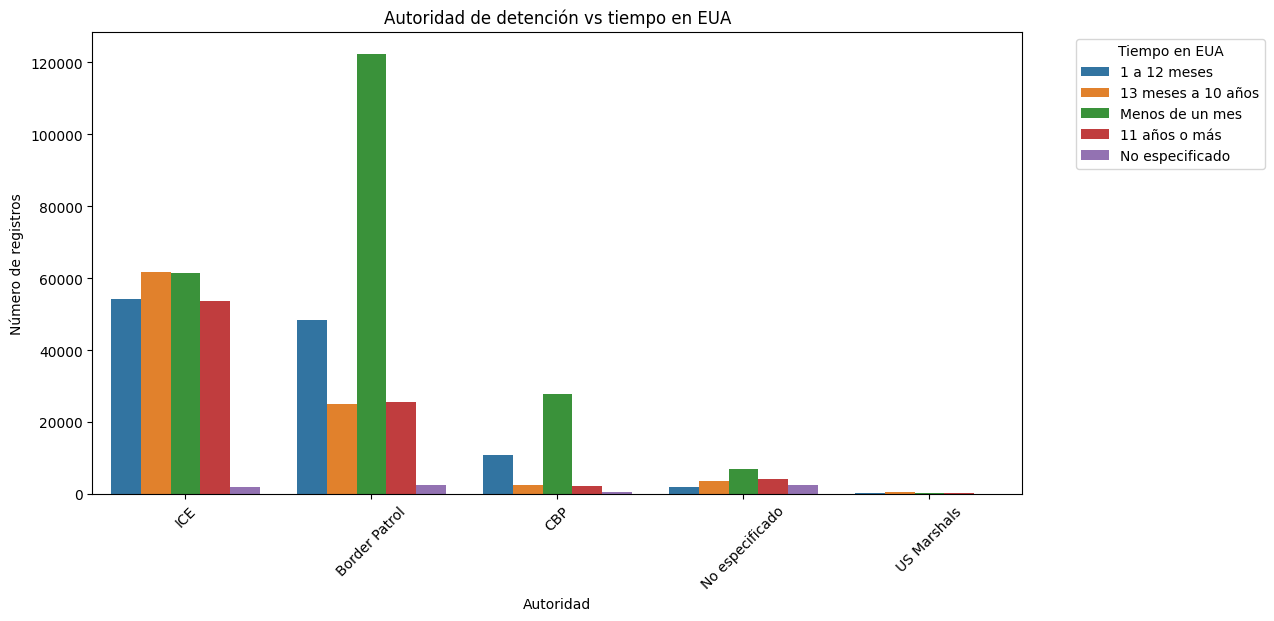

In [ ]:
# Autoridad vs grupo de edad
plt.figure(figsize=(10,6))
sns.countplot(x="autoridad", hue="grupo_de_edad", data=data,
              order=data['autoridad'].value_counts().index)
plt.title("Autoridad de detención vs grupo de edad")
plt.xlabel("Autoridad")
plt.ylabel("Número de registros")
plt.xticks(rotation=45)
plt.legend(title="Grupo de edad")
plt.show()

# Autoridad vs tiempo en EUA
plt.figure(figsize=(12,6))
sns.countplot(x="autoridad", hue="tiempo_en_eua", data=data,
              order=data['autoridad'].value_counts().index)
plt.title("Autoridad de detención vs tiempo en EUA")
plt.xlabel("Autoridad")
plt.ylabel("Número de registros")
plt.xticks(rotation=45)
plt.legend(title="Tiempo en EUA", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


# Anexos

## Descripción variables disponibles

* ano: No presenta problemas de calidad (sin nulos ni valores inválidos); su

* utilidad es principalmente cronológica, permitiendo segmentar tendencias y analizar evolución anual.

* mes: Distribución desigual con concentración en marzo y abril; puede capturar estacionalidad en los procesos de deportación y aportar contexto temporal en modelos.

* estado_recepcion: Alta concentración en Tamaulipas y Baja California, lo que refleja un sesgo geográfico; útil como predictor fronterizo y para análisis regional.

* punto_de_recepcion: Alta cardinalidad (32 valores) y concentración en pocos cruces; requiere codificación adecuada, pero aporta información logística sobre infraestructura de recepción.

* estado_origen: Distribución dispersa con predominio de “otros valores”; conviene agrupar estados poco frecuentes, aunque es valiosa para análisis regional de procedencia.

* estado_destino: Concentración en Baja California y Tamaulipas, redundante con estado_recepcion; puede servir para estudiar trayectorias internas y reasignaciones.

* estado_detencion_eua: Presenta errores tipográficos y falta de estandarización; tras limpieza puede usarse como indicador binario de “especificado/no especificado” o para análisis de origen en EUA.

* autoridad: ICE y Border Patrol concentran más del 85% de los registros, lo que limita diversidad; confiable como predictor institucional y diferenciador de procesos.

* sexo: Desbalance marcado (81% hombres); útil para segmentación demográfica, aunque requiere técnicas de balanceo para análisis predictivo.

* grupo_de_edad: Desbalance fuerte (90% adultos); aporta perfil migratorio, pero el sesgo hacia adultos limita representatividad de NNA.

* tiempo_en_eua: Mayoría en estancias cortas (<1 año); refleja perfiles migratorios de corta duración, útil para diferenciar trayectorias.

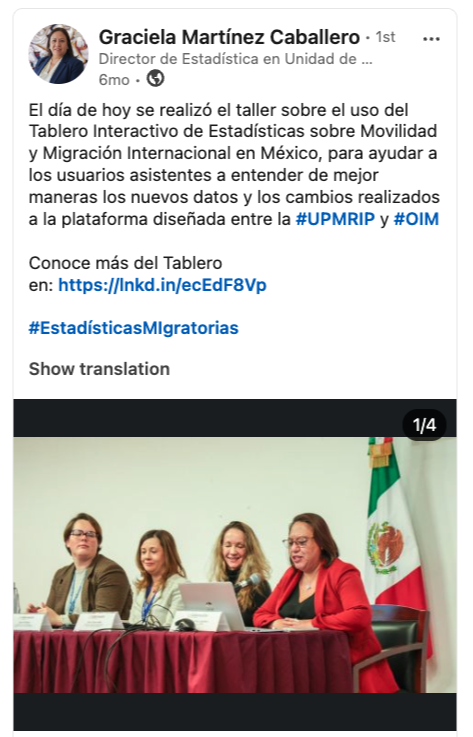